Fitness Tracker Conditional Worfkflow:

<pre>
               Input (steps, sleep, water)
                         |
               Calculate Wellness Score
                         |
                    Score Checker
                         |
   +---------------------+---------------------+
   |                     |                     |
 score < 1.5        1.5 ≤ score ≤ 2.2     score > 2.2
   |                     |                     |
LowHealthHandler   ModerateHealthHandler   HighHealthHandler
   |                     |                     |
   +---------------------+---------------------+
                         |
                       Output
</pre>


In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class Fitness(TypedDict):
    steps_walked : int
    sleep_hours : float
    water_liters : float

    score : float
    health_level : str
    recommendation : str

In [3]:
def score_calculation(state: Fitness):

    score = (state['steps_walked'] / 10000) + (state['sleep_hours'] / 8) + (state['water_liters'] / 3)

    return {'score': score}

In [4]:
def LowHealthHandler(state:Fitness):

    health_level = "LOW"

    recommendation = "Walk at least 3,000 more steps today, Drink at least 2 liters of water and Sleep at least 7 hours tonight"

    return {'health_level':health_level, 'recommendation':recommendation}

In [5]:
def ModerateHealthHandler(state:Fitness):

    health_level = "Moderate"

    recommendation = "Increase steps by 2,000 today, Maintain 7–8 hours of sleep and Drink 2.5 liters of water"
    
    return {'health_level':health_level, 'recommendation':recommendation}

In [6]:
def HighHealthHandler(state:Fitness):

    health_level = "HIGH"

    recommendation = "Try a 20-minute high-intensity workout, Maintain hydration above 3 liters and Track weekly progress and challenge yourself"

    return {'health_level':health_level, 'recommendation':recommendation}

In [7]:
def score_checker(state:Fitness) -> Literal["LowHealthHandler","ModerateHealthHandler","HighHealthHandler"]:

    if state['score']<1.5:
        return 'LowHealthHandler'
    elif state['score']>= 1.5 and state['score']<=2.2:
        return 'ModerateHealthHandler'
    else:
        return 'HighHealthHandler'



In [8]:
graph = StateGraph(Fitness)

In [9]:
graph.add_node('score_calculation',score_calculation)
graph.add_node('LowHealthHandler',LowHealthHandler)
graph.add_node('ModerateHealthHandler',ModerateHealthHandler)
graph.add_node('HighHealthHandler',HighHealthHandler)
# graph.add_node('score_checker',score_checker)

In [10]:
graph.add_edge(START, "score_calculation")

graph.add_conditional_edges(
    "score_calculation",
    score_checker
)

graph.add_edge("LowHealthHandler", END)
graph.add_edge("ModerateHealthHandler", END)
graph.add_edge("HighHealthHandler", END)

In [11]:
flow = graph.compile()

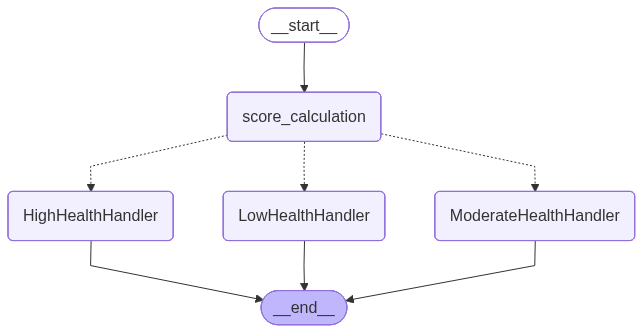

In [12]:
flow

In [22]:
input = {'steps_walked':100,'sleep_hours':8,'water_liters':21}

In [23]:
x = flow.invoke(input)

In [24]:
x

{'steps_walked': 100,
 'sleep_hours': 8,
 'water_liters': 21,
 'score': 8.01,
 'health_level': 'HIGH',
 'recommendation': 'Try a 20-minute high-intensity workout, Maintain hydration above 3 liters and Track weekly progress and challenge yourself'}